# Property Price Prediction - Analysis & Model Building

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [124]:
df = pd.read_csv("dataset/dataset.csv")
df.head()

,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,...,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [125]:
shape = df.shape
print(f"entries: {shape[0]} & features: {shape[1]}")

entries: 1460 & features: 81


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PropertyID            1460 non-null   int64  
 1   PropertyClass         1460 non-null   int64  
 2   PropertyZone          1460 non-null   str    
 3   PropertyFrontage      1201 non-null   float64
 4   PropertySize          1460 non-null   int64  
 5   Street                1460 non-null   str    
 6   Alley                 91 non-null     str    
 7   PropertyShape         1460 non-null   str    
 8   Elevation             1460 non-null   str    
 9   Amenities             1460 non-null   str    
 10  Orientation           1460 non-null   str    
 11  Grade                 1460 non-null   str    
 12  Neighborhood          1460 non-null   str    
 13  Condition1            1460 non-null   str    
 14  Condition2            1460 non-null   str    
 15  BldgType              1460 non-n

In [127]:
df.duplicated().sum()

np.int64(0)

## Basic Cleaning & Handling Missing Data

#### Handling Categorical cols

In [128]:
none_cols = [
    'PoolQC',
    'Alley',
    'QualFireplace',
    'BoundaryFeatures',
    'AddFeatures',
    'ExteriorCladdingType',
    'BasementType',
    'BasementFinish',
    'BasementQual',
    'BasementCond',
    'BsmntFinish'
]

for col in none_cols:
    df[col] = df[col].fillna("None")
    
mode_cols = [
    'Electrical',
    'BsmntMaintenance',
    'BsmntVisibility',
    'BsmntFinRat1',
    'BsmntFinQual1'
]

for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

> Missing values in these columns indicate the absence of the corresponding property feature rather than incomplete data. Therefore, missing values were replaced with "None" to preserve this information.

> Columns with a small number of missing categorical values were imputed using the mode, as it preserves the most frequently occurring category without significantly altering the data distribution.

#### Handling numerical cols

In [129]:
df["PropertyFrontage"] = (
    df.groupby("Neighborhood")["PropertyFrontage"]
      .transform(lambda x: x.fillna(x.median()))
)

df["ExteriorCladdingArea"] = df["ExteriorCladdingArea"].fillna(0)
df["BasementYrBlt"] = df["BasementYrBlt"].fillna(0)

garage_numeric = [
    "BasementCars",
    "BasementSqFootage"
]

for col in garage_numeric:
    df[col] = df[col].fillna(0)

- Missing values in PropertyFrontage were imputed using the median frontage within each neighborhood. This preserves local property characteristics and reduces the influence of outliers.
- Missing masonry veneer area values were replaced with 0, assuming the property has no masonry veneer.
- Missing garage construction years indicate the absence of a garage and were replaced with 0.
- Missing numerical garage-related values indicate that the property has no garage. Therefore, they were replaced with 0.


In [130]:
df.isnull().sum().sort_values(ascending=False).head(10)

PropertyID          0
PropertyClass       0
PropertyZone        0
PropertyFrontage    0
PropertySize        0
Street              0
Alley               0
PropertyShape       0
Elevation           0
Amenities           0
dtype: int64

In [131]:
num_cols = ["PropPrice", "PropertySize", "PropertyFrontage", "GrLivArea", "OverallQual", "OverallCond", "YearBuilt", "BasementSqFootage", "BasementCars", "WoodDeckSF", "OpenPorchSF"]
cat_cols = ["PropertyZone", "Neighborhood", "PropertyStyle", "BldgType", "SaleType", "KitchenQual", "ExterQual"]
target_col = 'PropPrice'

## 1. Univariate Analysis

- ### Summary

In [132]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PropPrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.00,755000.0
PropertySize,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
PropertyFrontage,1460.0,70.199658,22.431902,21.0,60.0,70.0,80.00,313.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.5,1464.0,1776.75,5642.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.0,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.0,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
BasementSqFootage,1460.0,472.980137,213.804841,0.0,334.5,480.0,576.00,1418.0
BasementCars,1460.0,1.767123,0.747315,0.0,1.0,2.0,2.00,4.0
WoodDeckSF,1460.0,94.244521,125.338794,0.0,0.0,0.0,168.00,857.0


In [133]:
df[cat_cols].describe(include='str').T

,count,unique,top,freq
PropertyZone,1460,5,RL,1151
Neighborhood,1460,25,NAmes,225
PropertyStyle,1460,8,1Story,726
BldgType,1460,5,1Fam,1220
SaleType,1460,9,WD,1267
KitchenQual,1460,4,TA,735
ExterQual,1460,4,TA,906


In [134]:
def check_skewness(col):
    val = col.skew()
    
    if -0.5 <= val <= 0.5:
        return "Symmetrical (Normal-ish)"
    elif 0.5 < val <= 1:
        return "Moderately Positive Skewed"
    elif val > 1:
        return "Highly Positive Skewed"
    elif -1 <= val < -0.5:
        return "Moderately Negative Skewed"
    else:
        return "Highly Negative Skewed"

def check_kurtosis(col):
    val = col.kurt()
    
    if val > 0.5:
        return "Leptokurtic (Heavy Tails / Peaked)"
    elif val < -0.5:
        return "Platykurtic (Light Tails / Flat)"
    else:
        return "Mesokurtic (Normal-like)"

- ### Continious

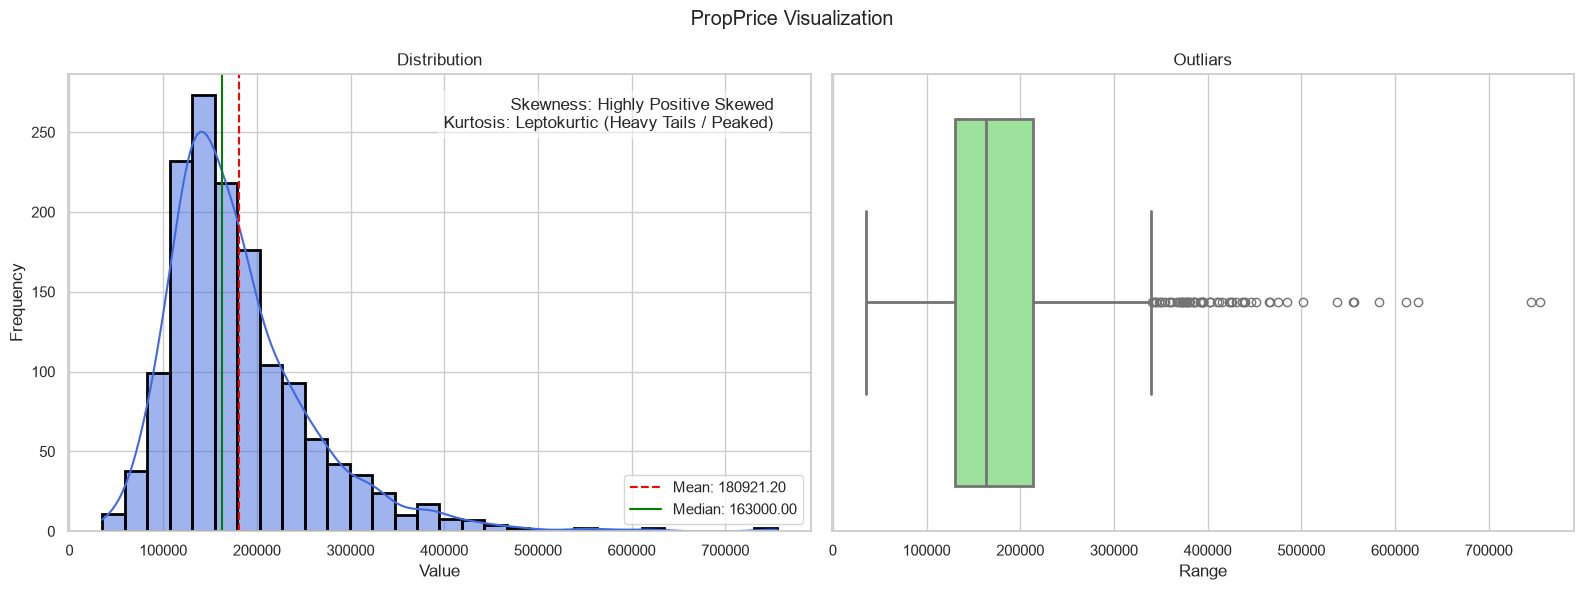

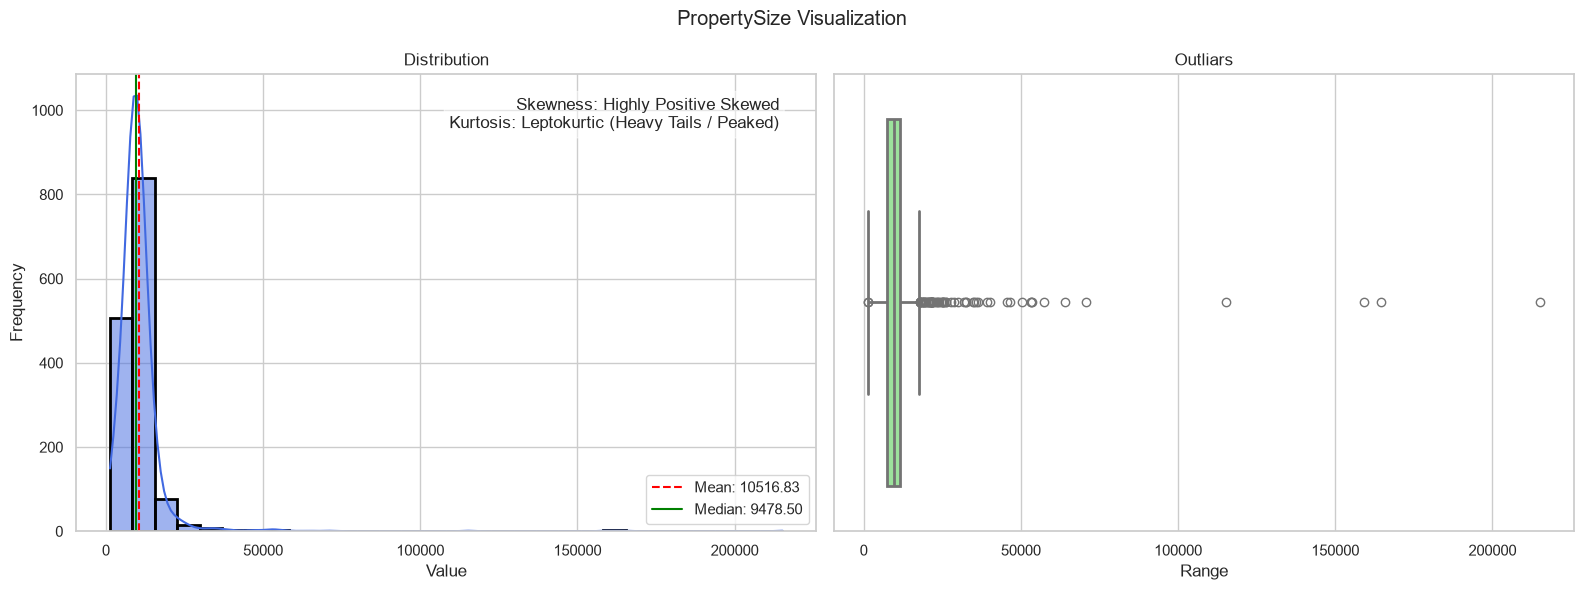

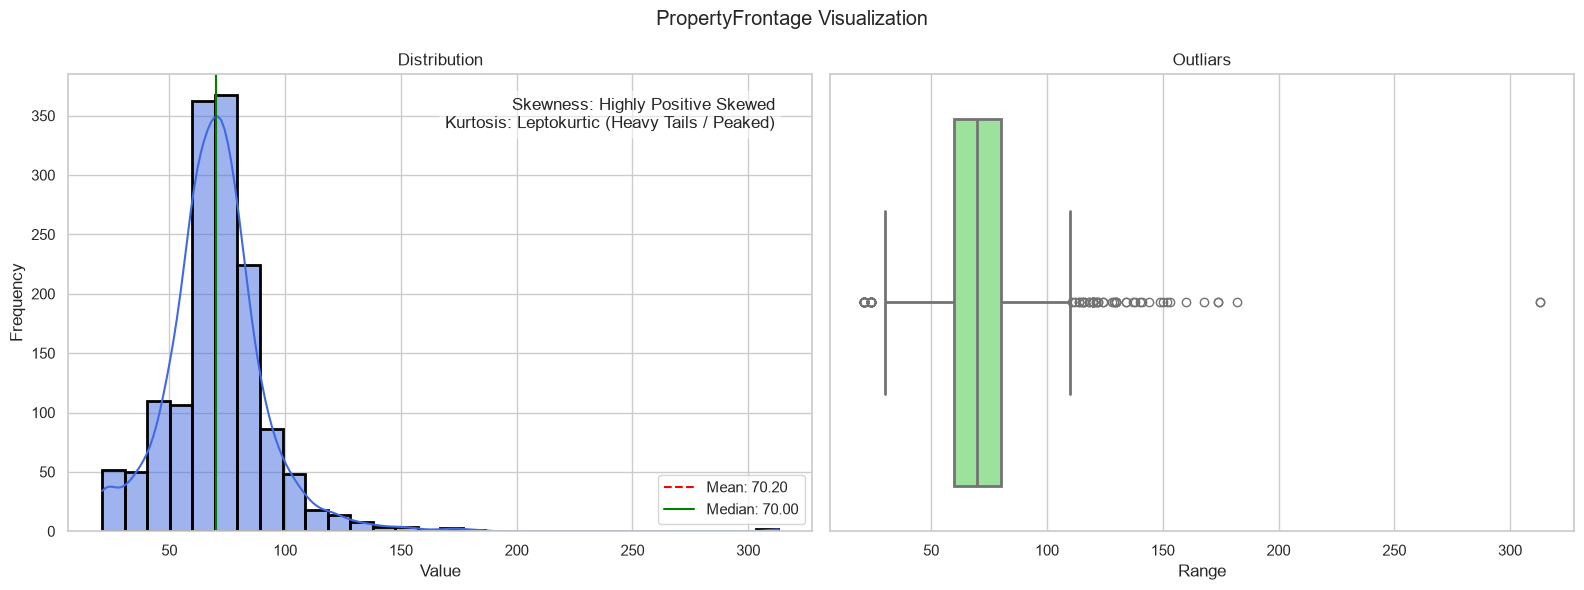

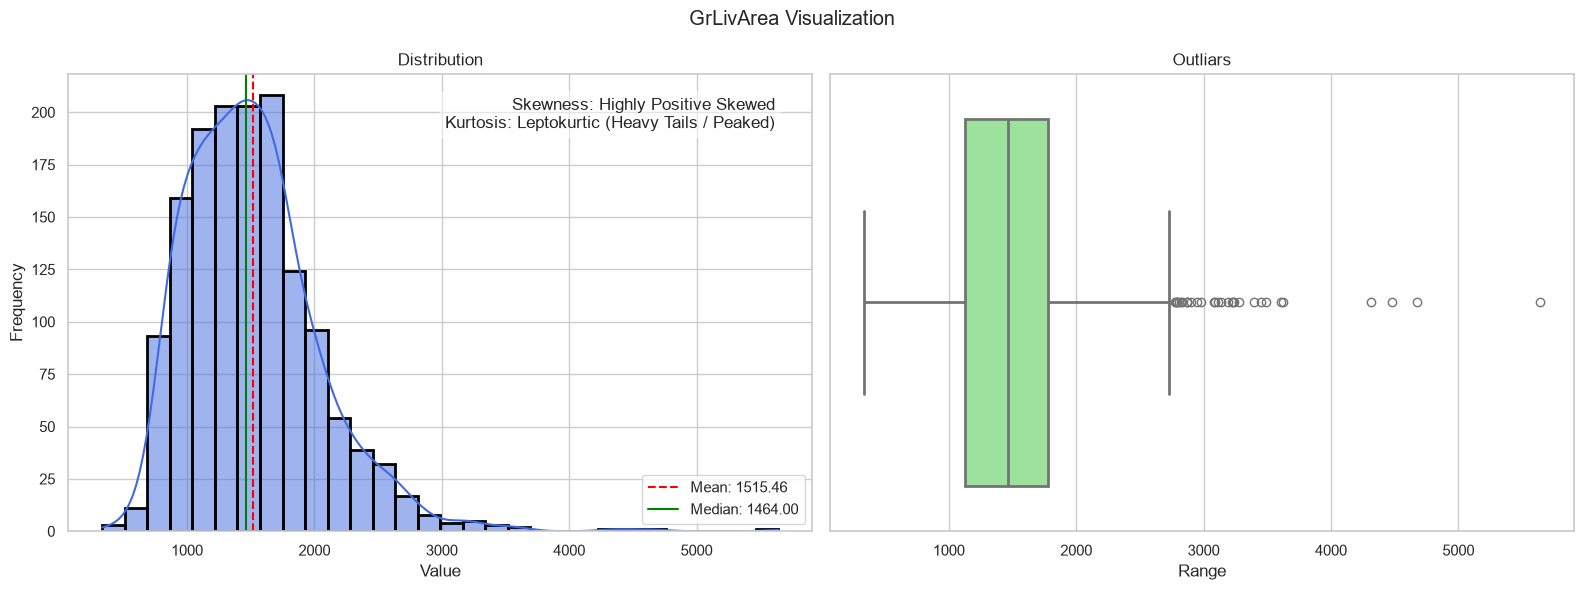

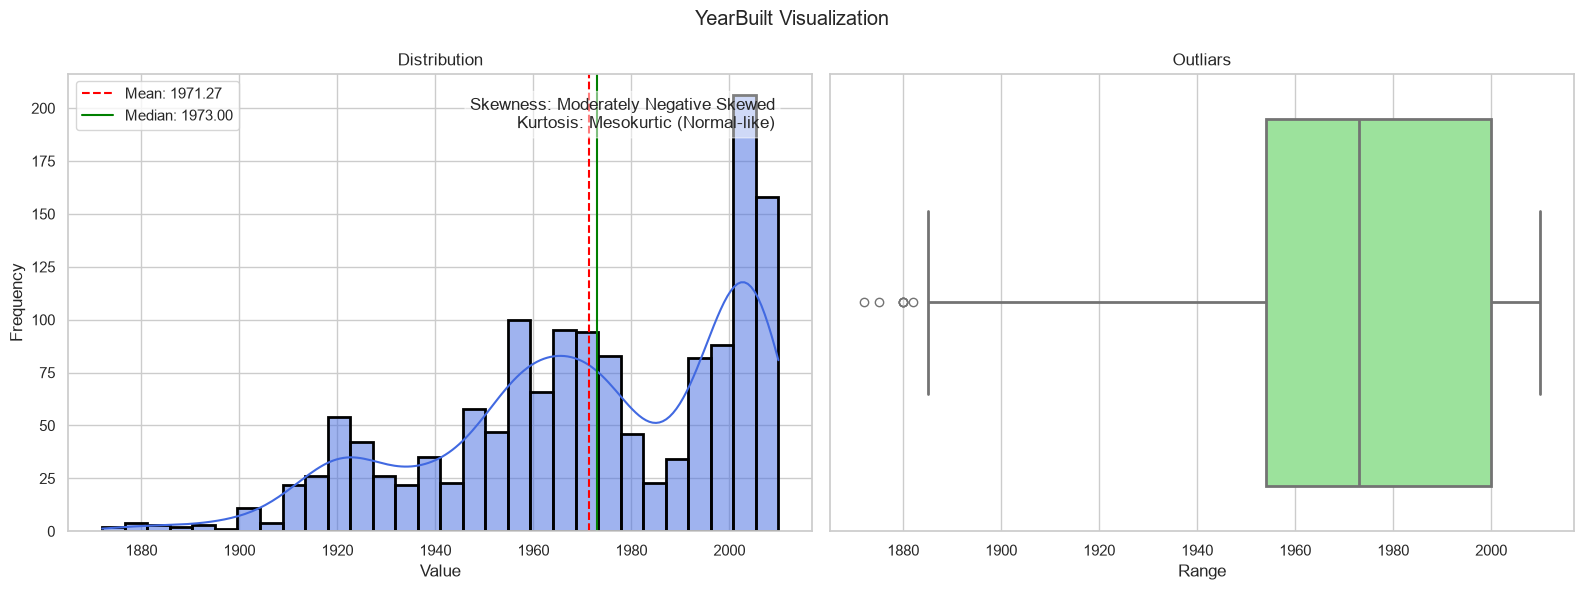

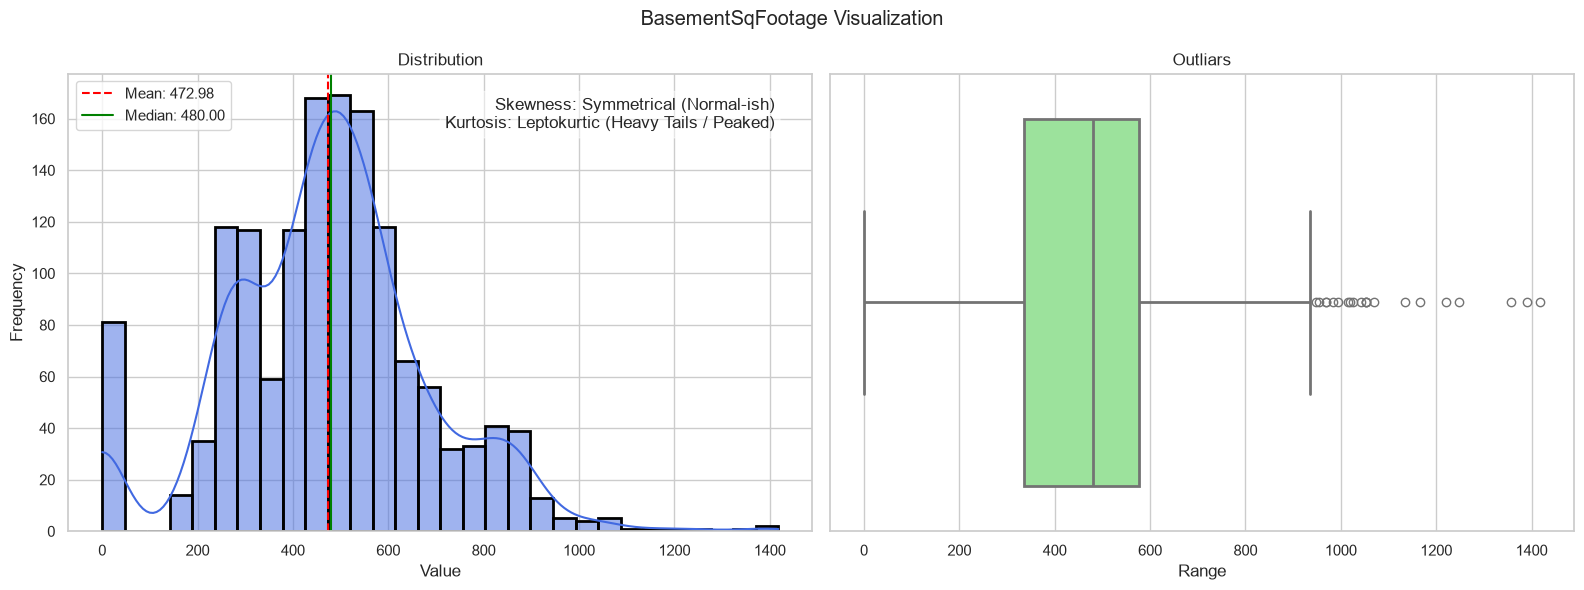

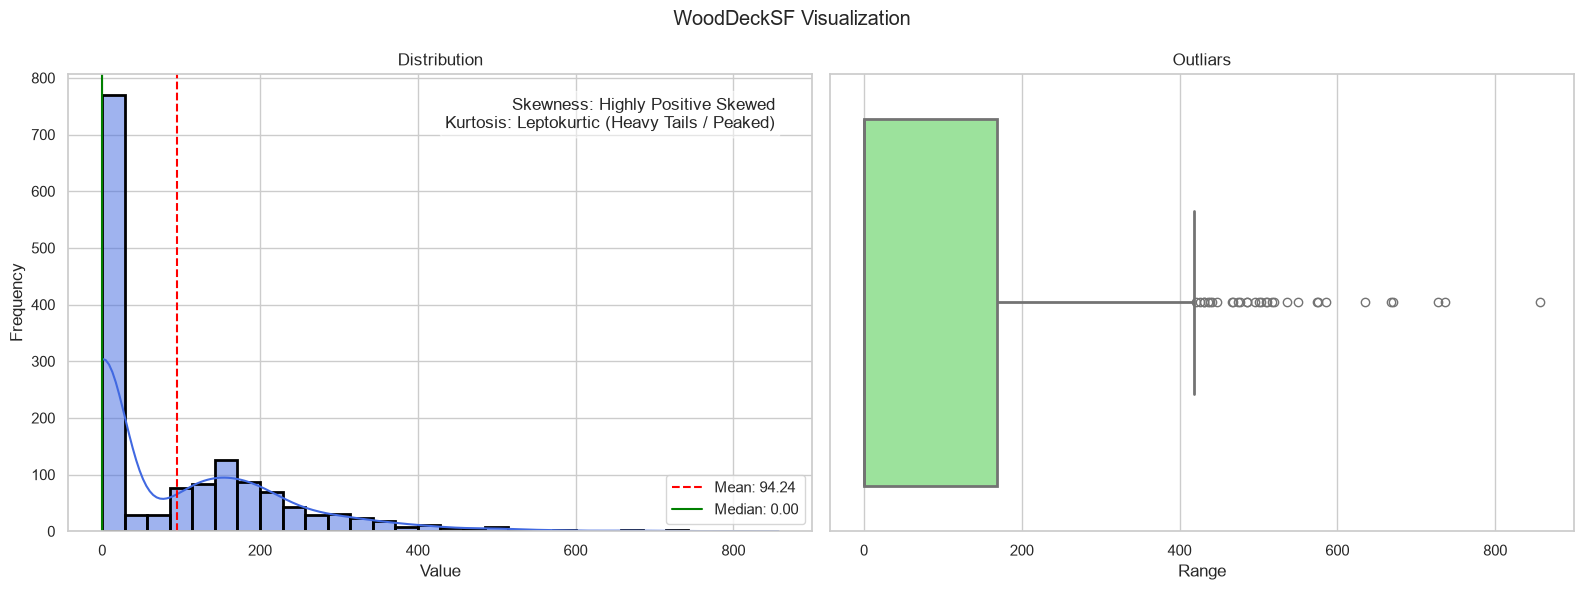

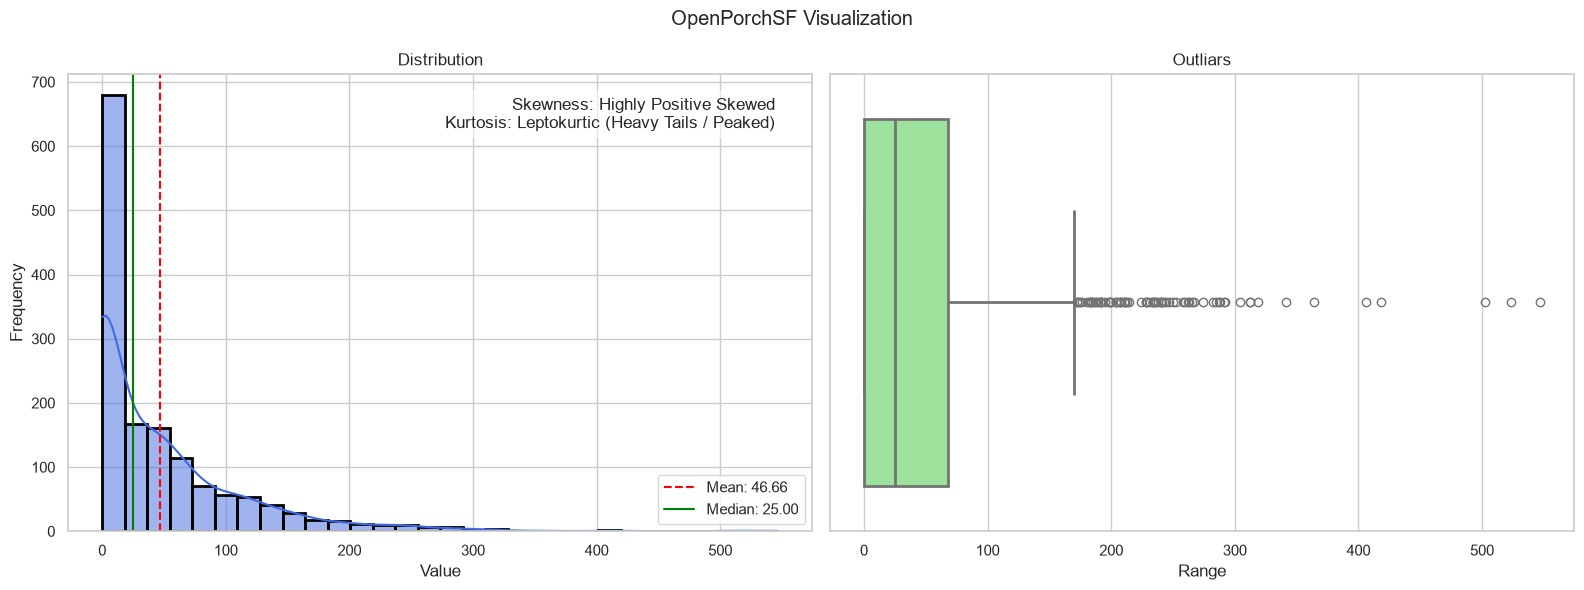

In [135]:
sns.set_theme(style="whitegrid")
cont_cols = ["PropPrice", "PropertySize", "PropertyFrontage", "GrLivArea", "YearBuilt", "BasementSqFootage", "WoodDeckSF", "OpenPorchSF"]

for i, curr_col in enumerate(cont_cols):
    fig = plt.figure(figsize=(16, 6))
    
    # mean median vals
    mean_val = df[curr_col].mean()
    median_val = df[curr_col].median()

    # Histogram
    plt.subplot(1, 2, 1)
    ax1 = sns.histplot(data=df, x=curr_col, linewidth=2, bins=30, color="royalblue", edgecolor="black", kde=True)

    # Mean & Median lines
    ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

    # Skewness and kurtosis labels
    stats_text = f'Skewness: {check_skewness(df[curr_col])}\nKurtosis: {check_kurtosis(df[curr_col])}'
    ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    ax1.legend()

    ax1.set_title('Distribution')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Frequency')

    plt.subplot(1, 2, 2)
    ax2 = sns.boxplot(data=df, x=curr_col, color="lightgreen", linewidth=2)
    ax2.set_title('Outliars')
    ax2.set_xlabel('Range')

    fig.suptitle(f"{curr_col} Visualization")
    plt.tight_layout()
    plt.show()

### Interpretation

- The continuous variables exhibit varying distributions, with most features showing positive skewness where a large proportion of observations are concentrated at lower values and fewer observations occur at higher values.
- The boxplots indicate the presence of outliers in variables such as `PropPrice`, `PropertySize`, `GrLivArea`, `BasementSqFootage`, and `PropertyFrontage`. In the context of real estate, these observations are likely to represent genuinely large or premium properties rather than data entry errors.
- Variables such as `YearBuilt` show a relatively balanced distribution, whereas variables representing area measurements contain greater variability across properties.
- Overall, the continuous variables provide sufficient variation for predictive modeling and no continuous feature appears to contain unrealistic distributions that require immediate removal.

- ### Discrete

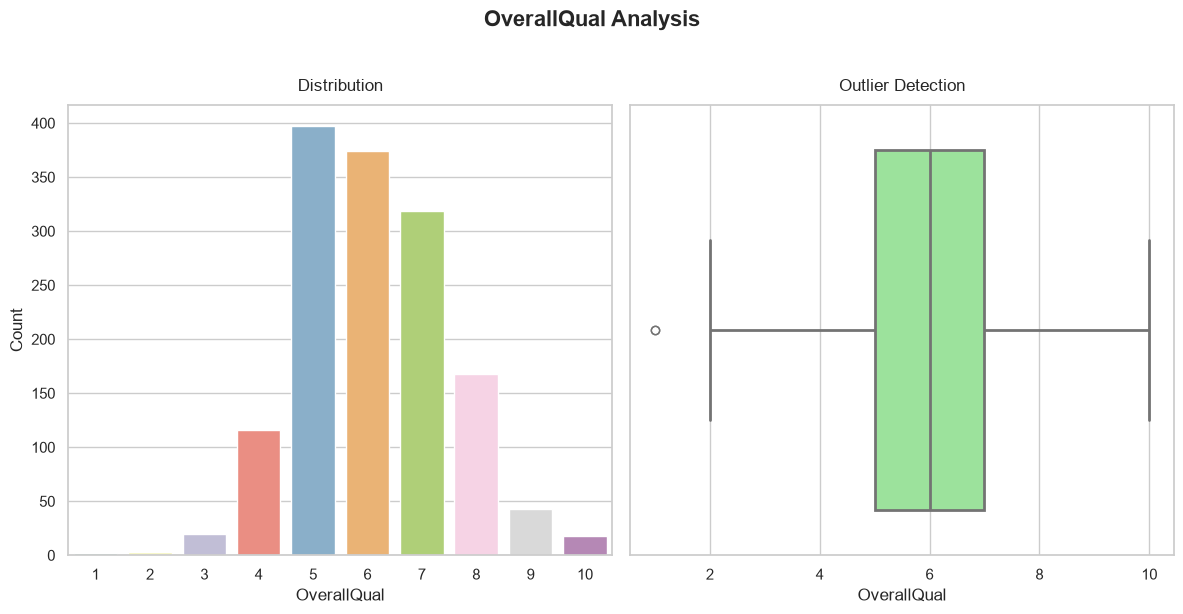

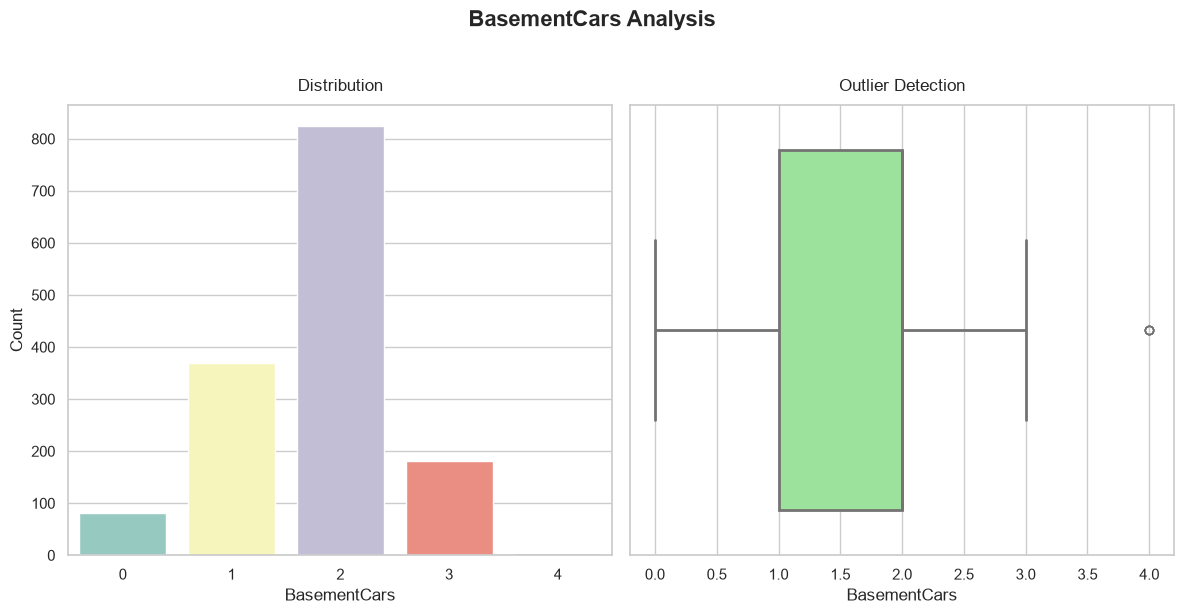

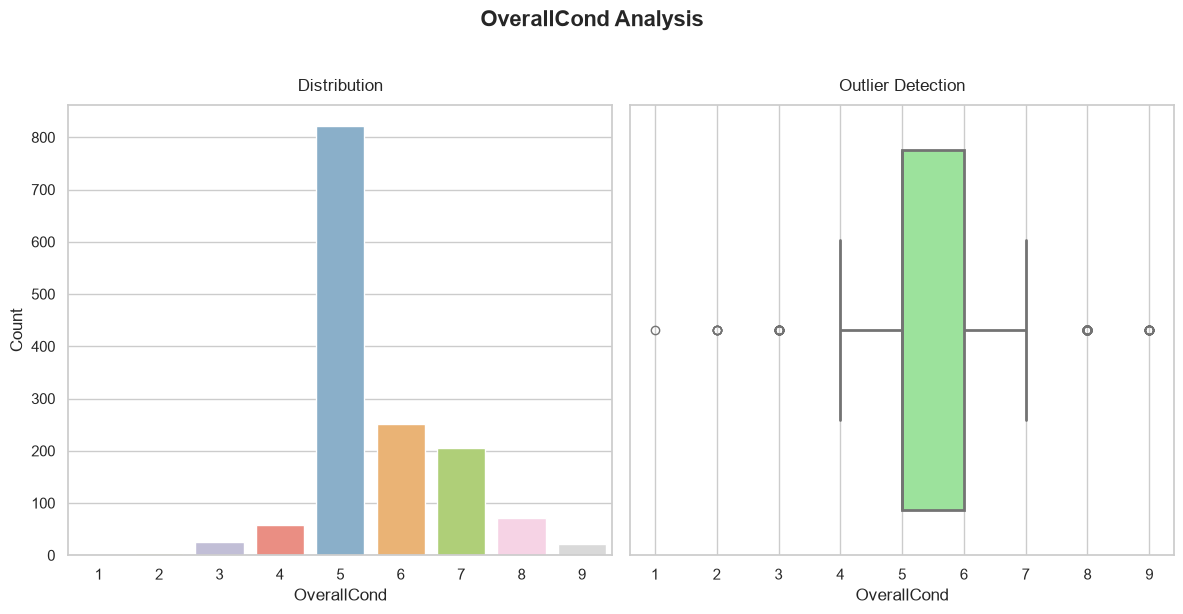

In [136]:
disc_cols = ["OverallQual", "BasementCars", "OverallCond"]

for curr_col in disc_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"{curr_col} Analysis", fontsize=16, fontweight='bold', y=1.02)

    # distribution
    sns.countplot(data=df, x=curr_col, palette="Set3", hue=curr_col, legend=False, ax=ax1)
    
    ax1.set_title('Distribution', fontsize=12, pad=10)
    ax1.set_xlabel(curr_col)
    ax1.set_ylabel('Count')

    # Outliars
    sns.boxplot(data=df, x=curr_col, color="lightgreen", linewidth=2, ax=ax2)
    
    ax2.set_title('Outlier Detection', fontsize=12, pad=10)
    ax2.set_xlabel(curr_col)

    plt.tight_layout()
    plt.show()

### Interpretation

- The discrete variables are concentrated around a few common values, indicating that most properties belong to average quality, average condition, and medium garage capacity categories.
- Extreme ratings occur less frequently, suggesting that exceptionally poor or exceptionally high-quality properties represent only a small proportion of the dataset.
- The boxplots do not reveal abnormal behaviour because these variables contain limited integer categories by definition.
- These features are expected to contribute significantly to property price prediction because they describe important structural characteristics of residential properties.

- ### Categorical

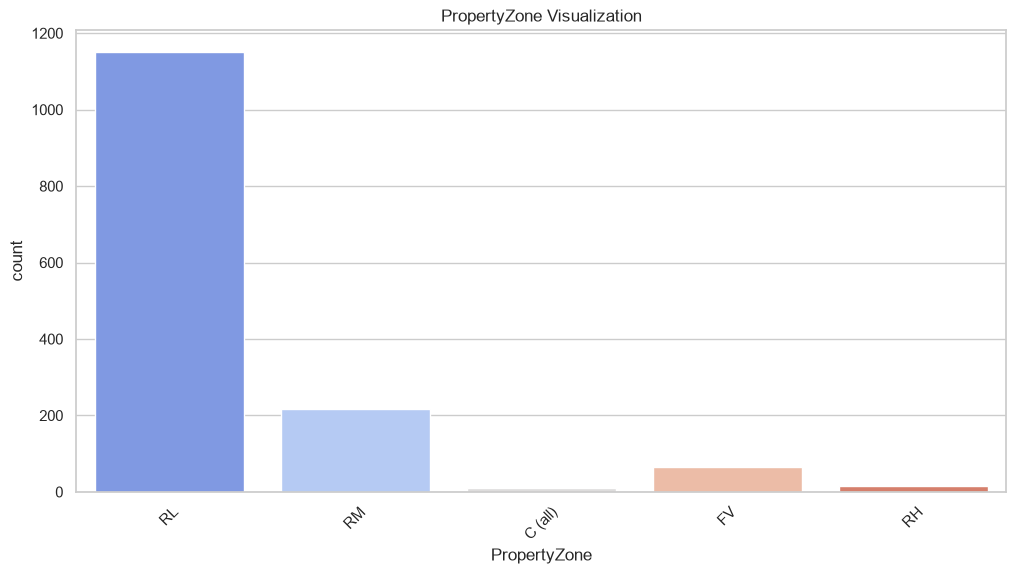

PropertyZone
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

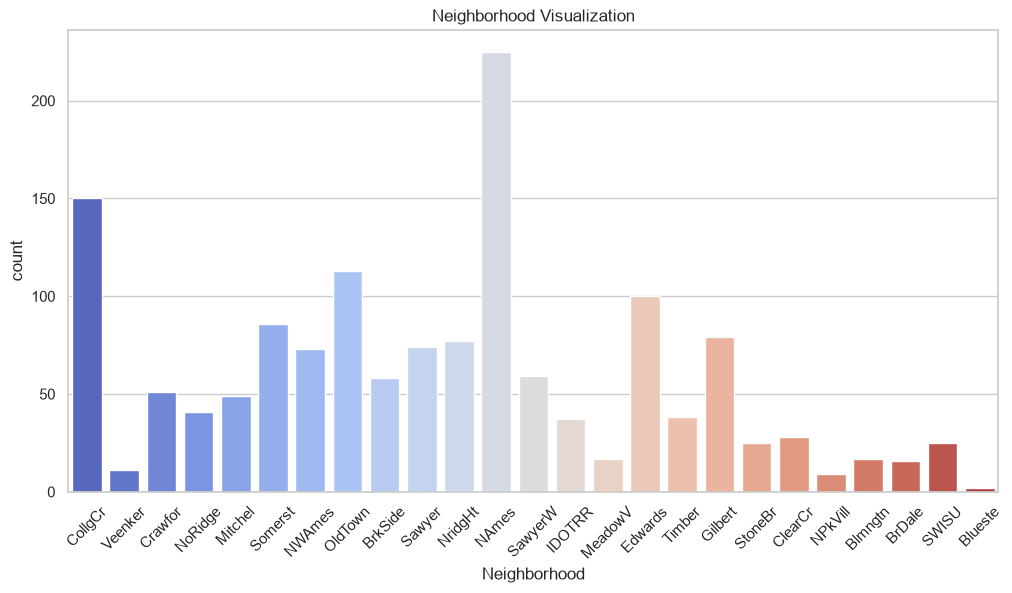

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

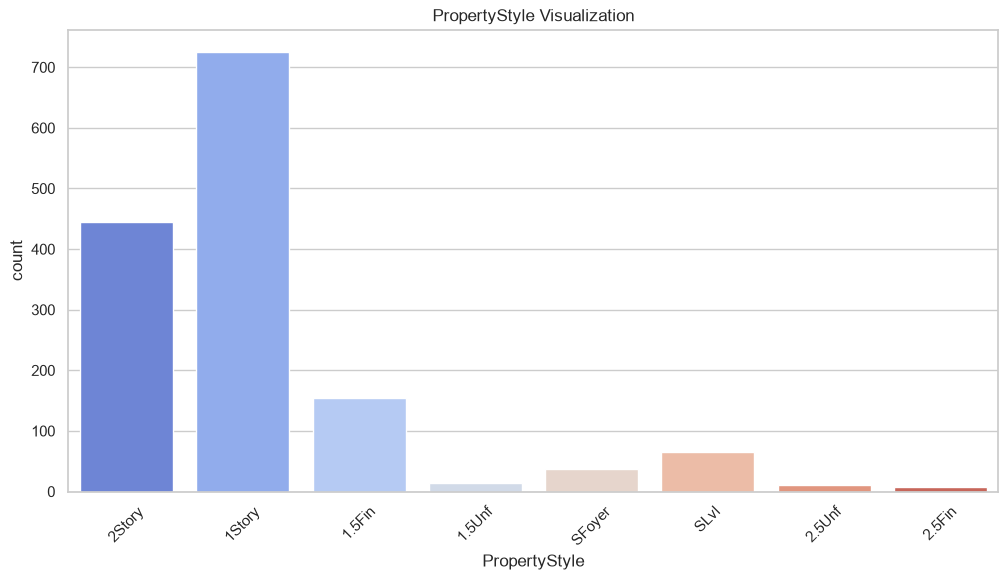

PropertyStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

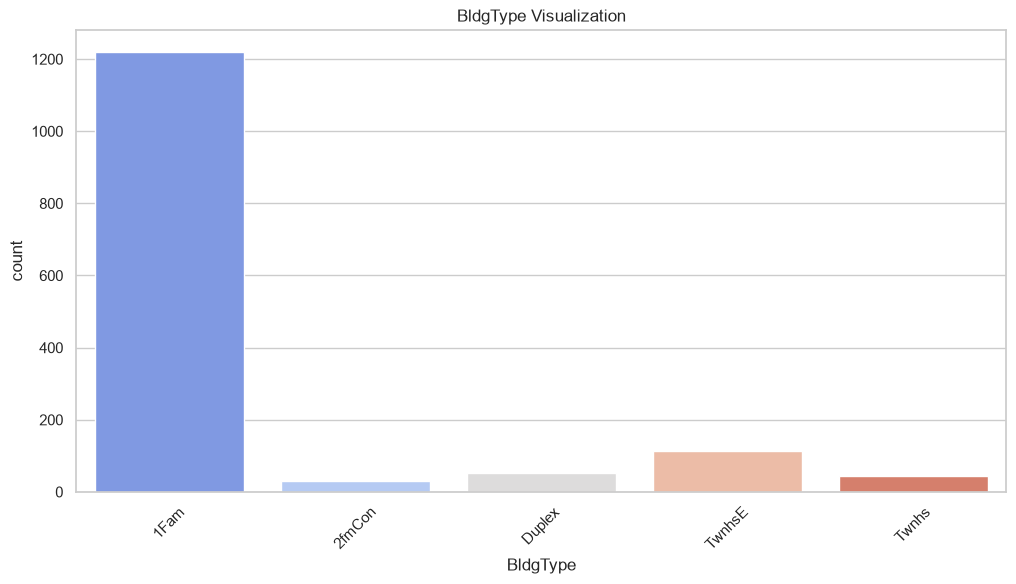

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

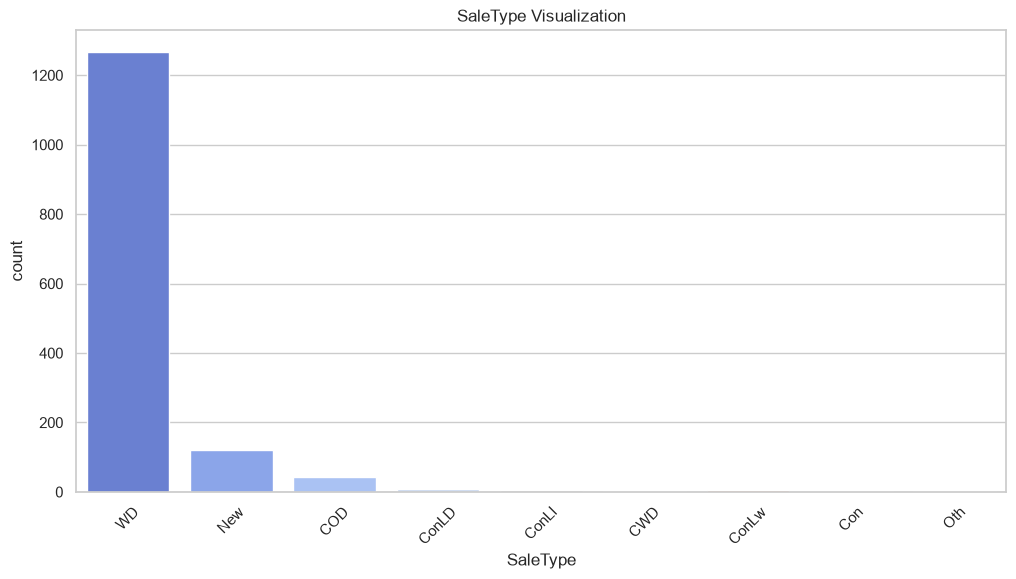

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

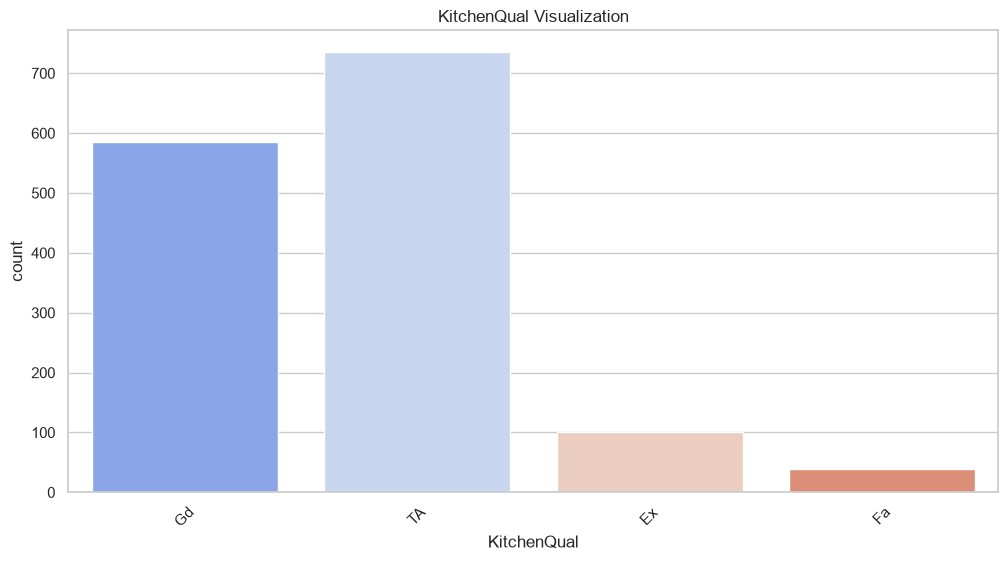

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

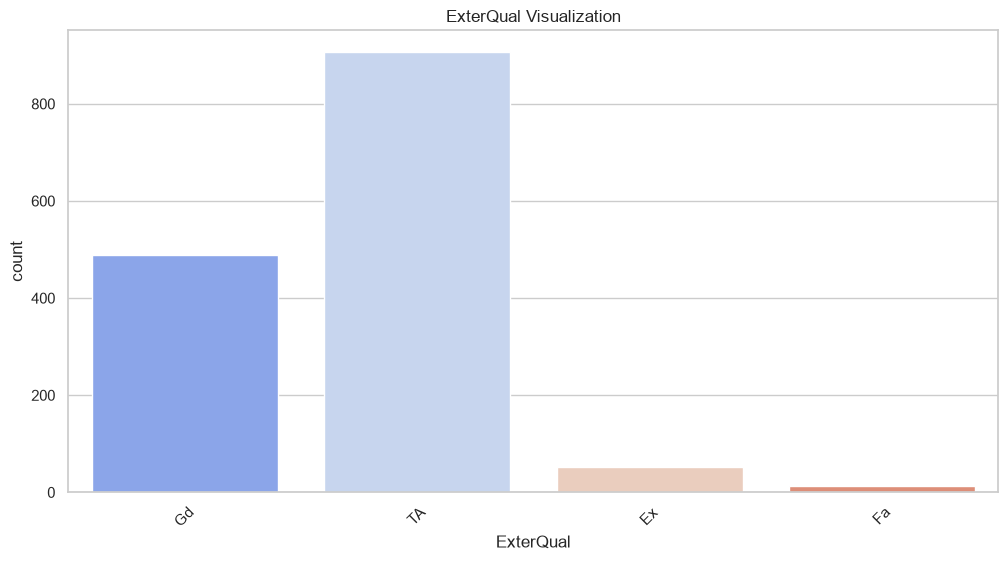

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

In [137]:

for curr_col in cat_cols:
    plt.figure(figsize=(12, 6))
    
    # distribution
    sns.countplot(data=df, x=curr_col, hue=curr_col, palette='coolwarm')
    plt.title(f'{curr_col} Visualization')
    plt.xticks(rotation=45)
    plt.show()
    
    display(df[curr_col].value_counts())

### Interpretation

- The countplots show that several categorical variables are dominated by one or two categories, indicating that the housing market represented in the dataset mainly consists of common residential property types.
- Categories such as neighborhoods, zoning classifications, sale types, and property styles are not uniformly distributed, reflecting the natural composition of the real estate market.
- Some categories contain relatively few observations; however, these represent genuine market diversity and should be retained during modeling.
- Since these variables are categorical in nature, appropriate encoding techniques will be applied during preprocessing before training machine learning models.

## 2. Bivariate Analysis

- ### Numerical vs Target

C:\Users\sansk\AppData\Local\Temp\ipykernel_13252\2180358042.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


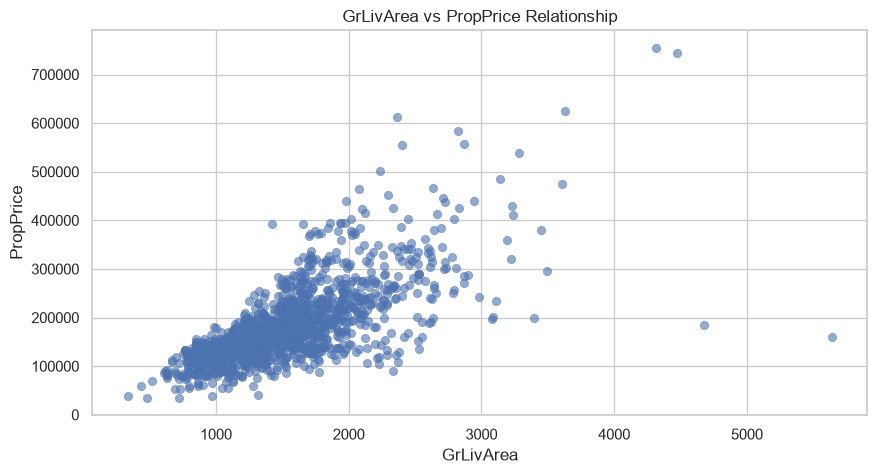

C:\Users\sansk\AppData\Local\Temp\ipykernel_13252\2180358042.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


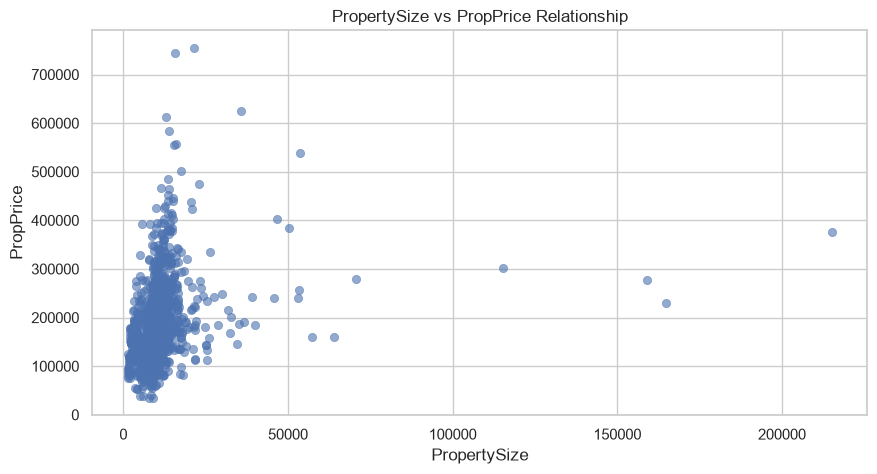

C:\Users\sansk\AppData\Local\Temp\ipykernel_13252\2180358042.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


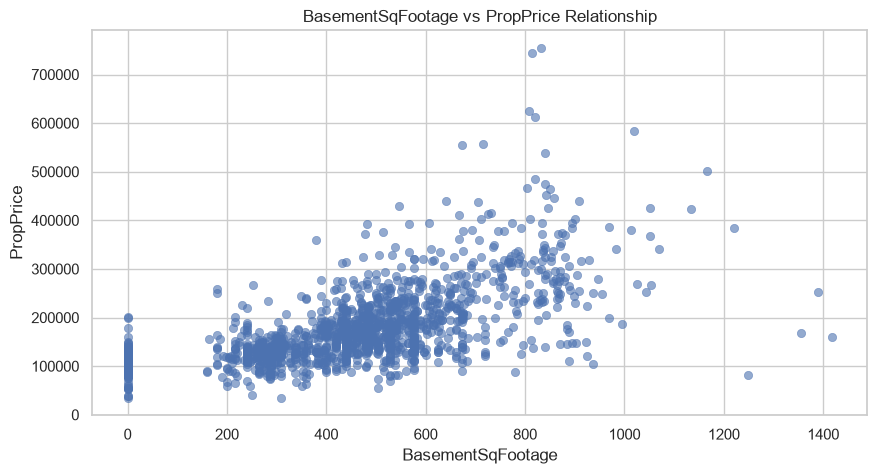

In [138]:
for curr_col in ["GrLivArea", "PropertySize", "BasementSqFootage"]:
    plt.figure(figsize=(10, 5))
    
    # Cleaned up scatterplot call (removed unused 'palette' since y is continuous)
    sns.scatterplot(
        data=df, 
        x=curr_col, 
        y=target_col,
        palette='Set1',  # A clean, single-color anchor from the 'magma' palette
        alpha=0.6,        # Adds transparency to see overlapping data points clearly
        edgecolor=None    # Removes distracting outlines around points
    )
    plt.title(f'{curr_col} vs {target_col} Relationship')
    plt.show()

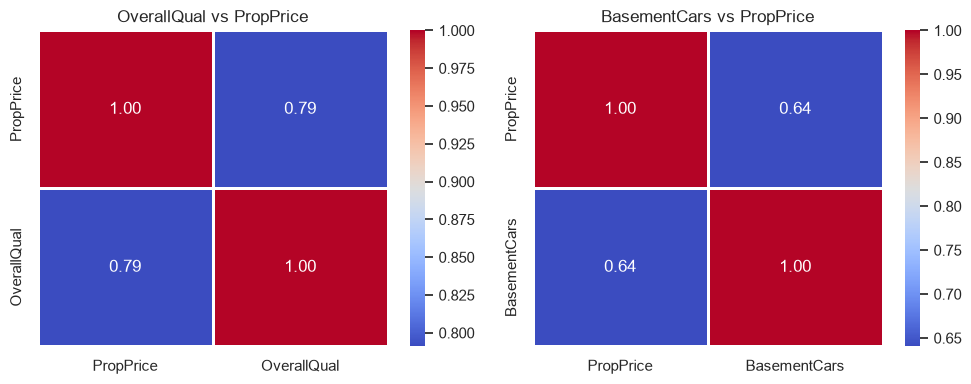

In [139]:
# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, curr_col in enumerate(["OverallQual", "BasementCars"]):
    # Calculate the correlation matrix
    corr_table = df[[target_col, curr_col]].corr()
    
    # Plot on the specific subplot axis
    sns.heatmap(
        corr_table,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=2,
        ax=axes[i]  # <-- Directs the plot to the correct subplot
    )
    
    # Set title for the individual subplot
    axes[i].set_title(f'{curr_col} vs {target_col}')

# Adjust layout to prevent overlap and display the plot
plt.tight_layout()
plt.show()

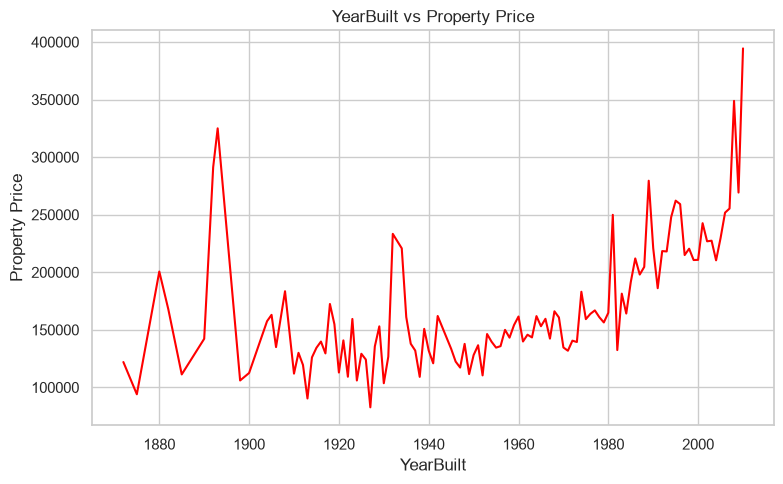

In [140]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df.sort_values('YearBuilt'),
    x='YearBuilt',
    y='PropPrice',
    estimator='mean',
    errorbar=None,
    color='red'
)

plt.title("YearBuilt vs Property Price")
plt.xlabel("YearBuilt")
plt.ylabel("Property Price")

plt.tight_layout()
plt.show()

### Interpretation

- The scatterplots reveal a positive relationship between `GrLivArea`, `PropertySize`, `BasementSqFootage`, and `PropPrice`, indicating that larger properties generally command higher selling prices.
- Although some variation exists among observations, the overall upward trend suggests that these numerical variables are important predictors of property price.
- The correlation matrices further confirm that `OverallQual` and `BasementCars` have positive associations with the target variable, highlighting their influence on house valuation.
- These findings indicate that both property size and structural quality are key factors affecting residential property prices.

- ### Categorical vs Target

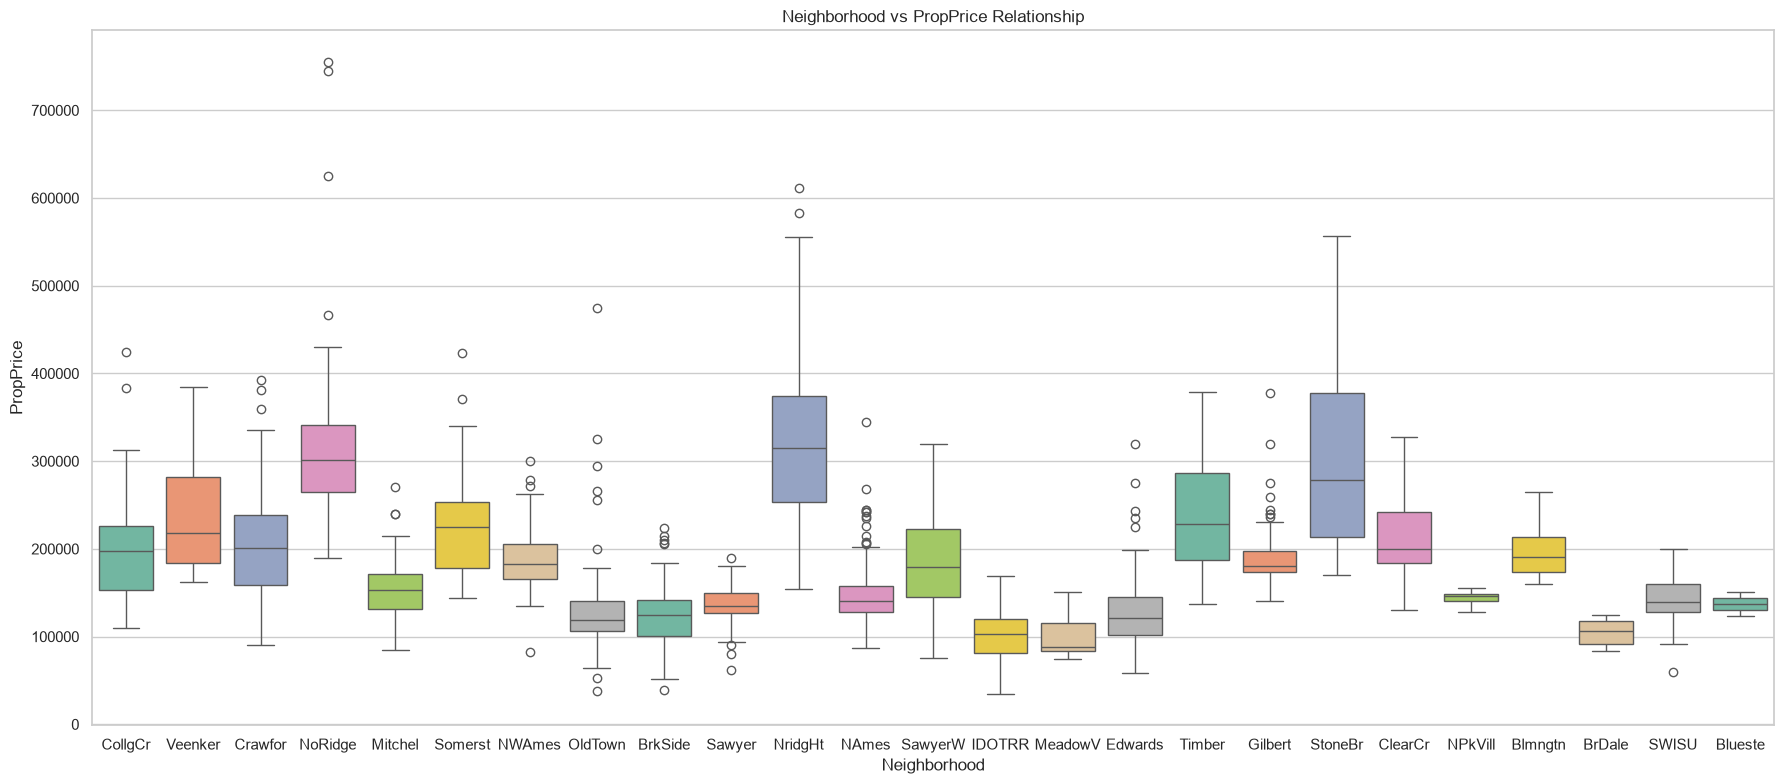

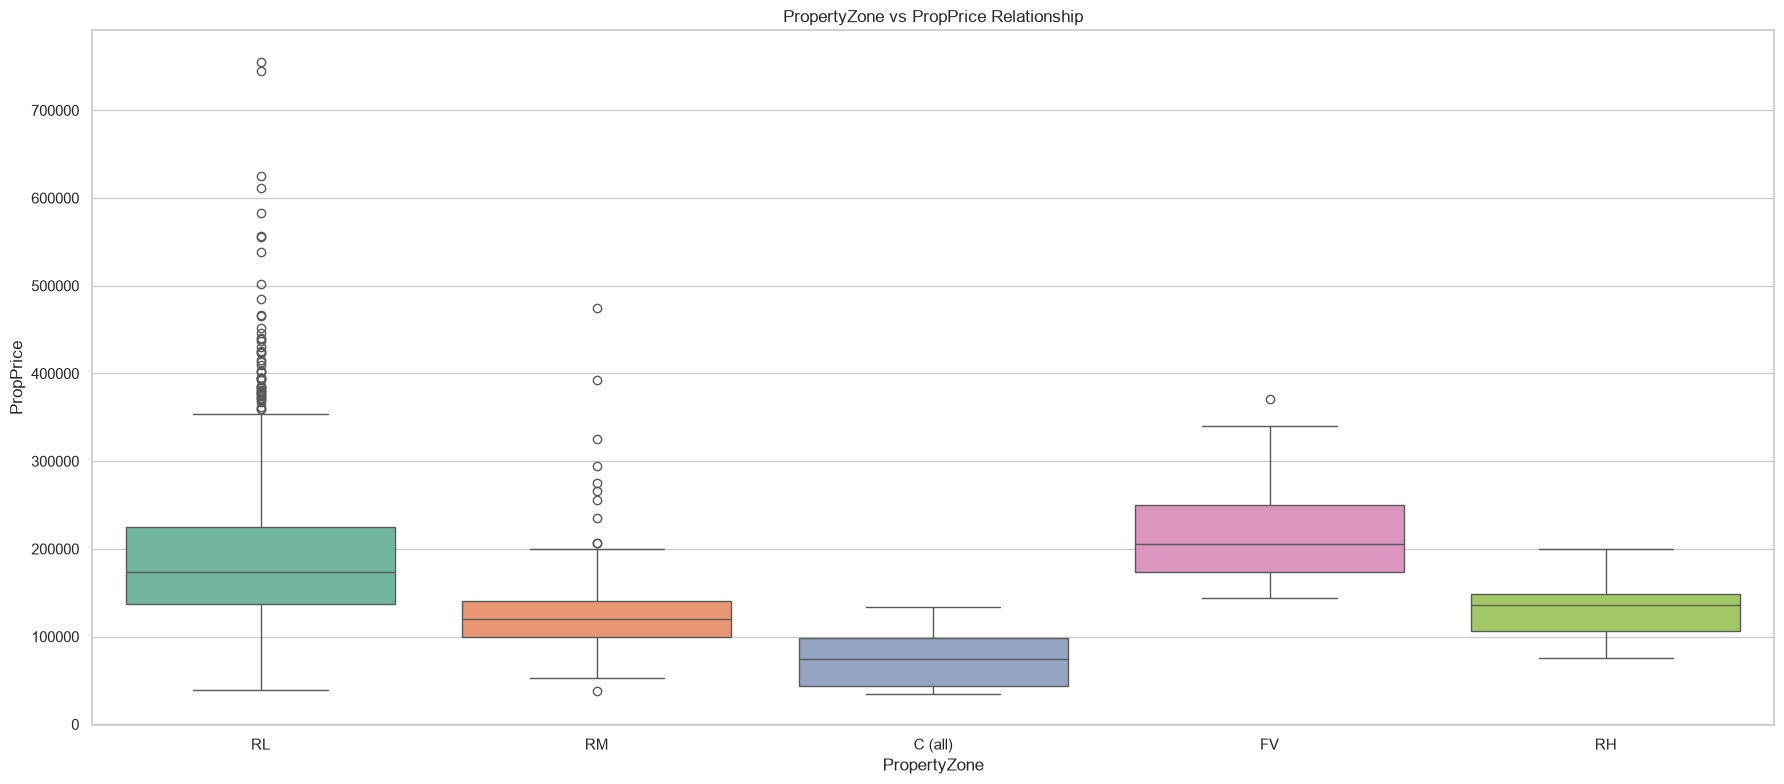

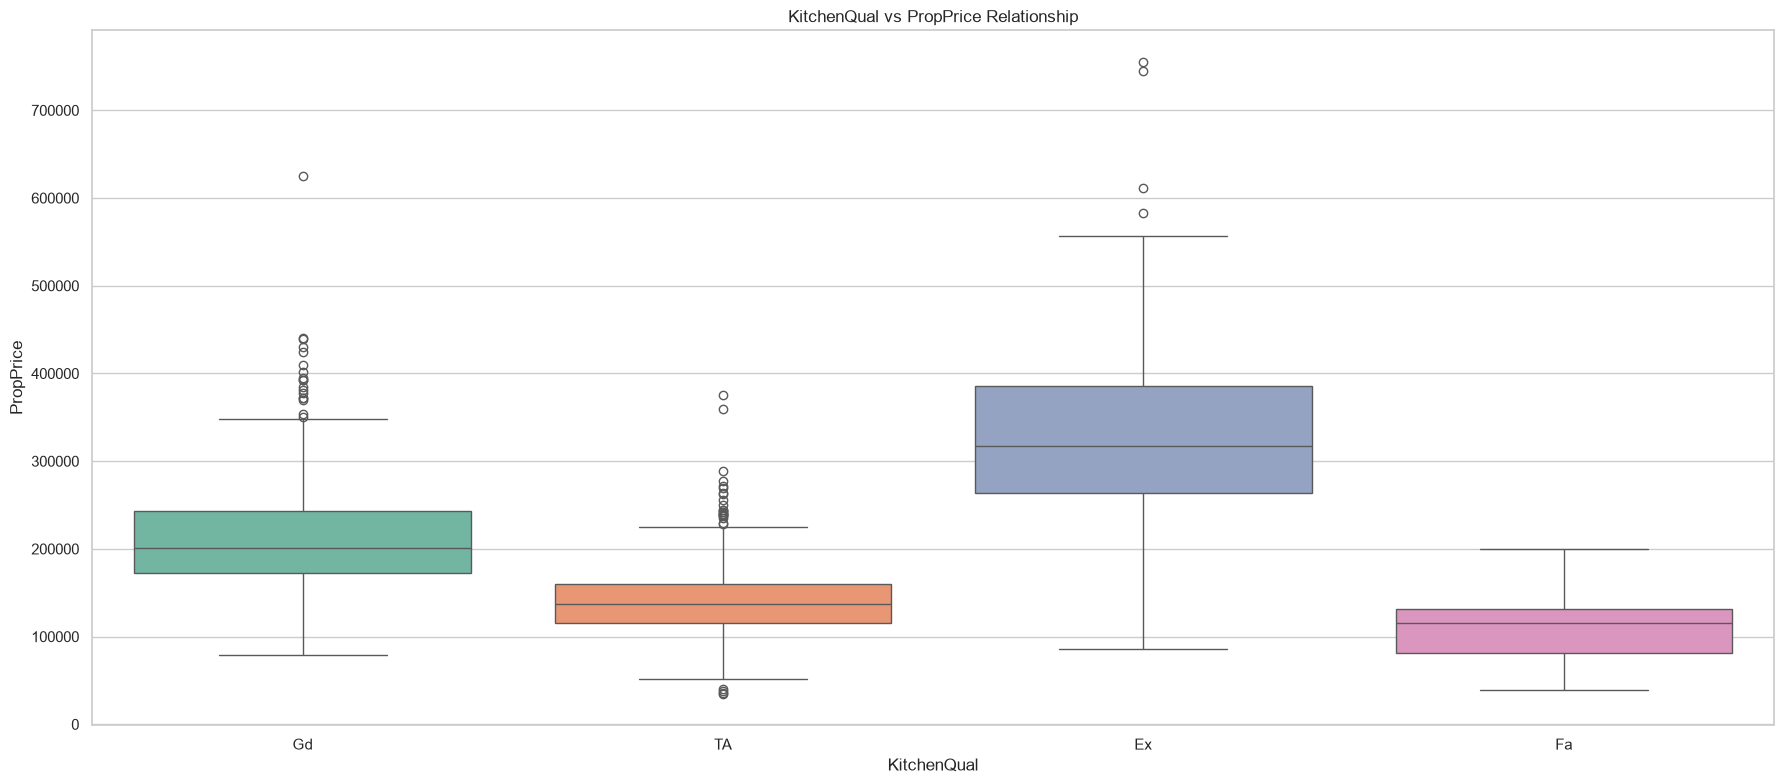

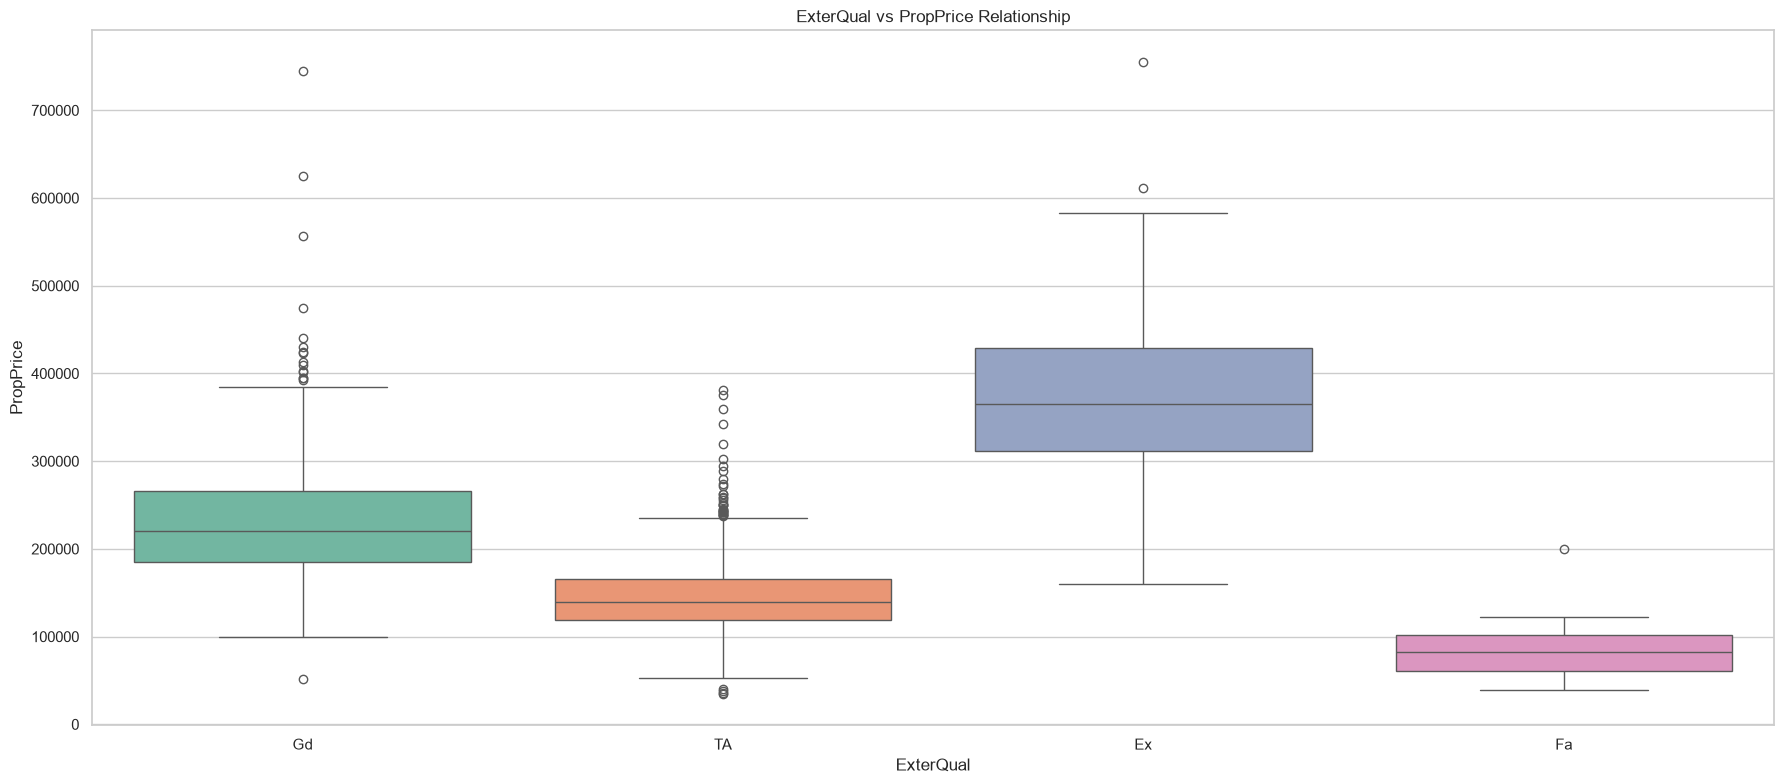

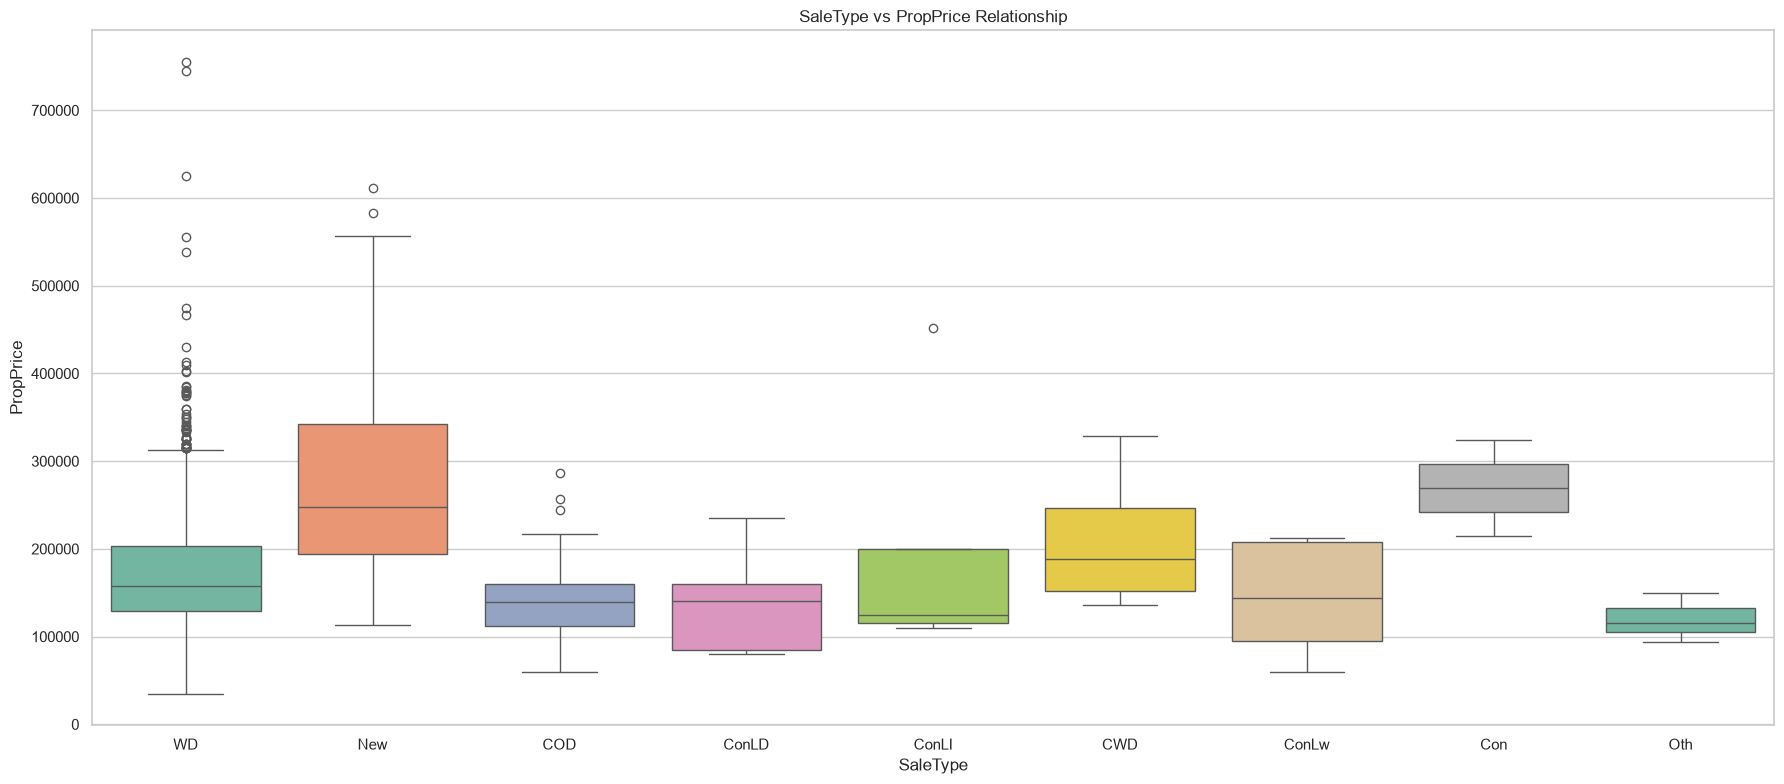

In [141]:
for curr_col in ["Neighborhood", "PropertyZone", "KitchenQual", "ExterQual", "SaleType"]:
    plt.figure(figsize=(18, 8))
    
    sns.boxplot(
        data=df, 
        x=curr_col, 
        y=target_col,
        hue=curr_col,
        legend=False,
        palette='Set2'
    )
    plt.title(f'{curr_col} vs {target_col} Relationship')
    plt.tight_layout()
    plt.show()

### Interpretation

- The boxplots demonstrate noticeable differences in property prices across different categories of neighborhoods, zoning classifications, kitchen quality, exterior quality, and sale types.
- Properties with higher quality ratings generally exhibit higher median selling prices, indicating that construction quality has a substantial impact on market value.
- Similarly, certain neighborhoods and zoning categories consistently show higher price distributions, suggesting that location remains one of the strongest determinants of property value.
- The observed variation confirms that categorical variables contain valuable predictive information and should be appropriately encoded before model training.

## 3. Multivariate Analysis

- ### Correlation Matrix

In [142]:
corr_cols = [
    'PropPrice',
    'PropertySize',
    'PropertyFrontage',
    'GrLivArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'BasementSqFootage',
    'BasementCars'
]

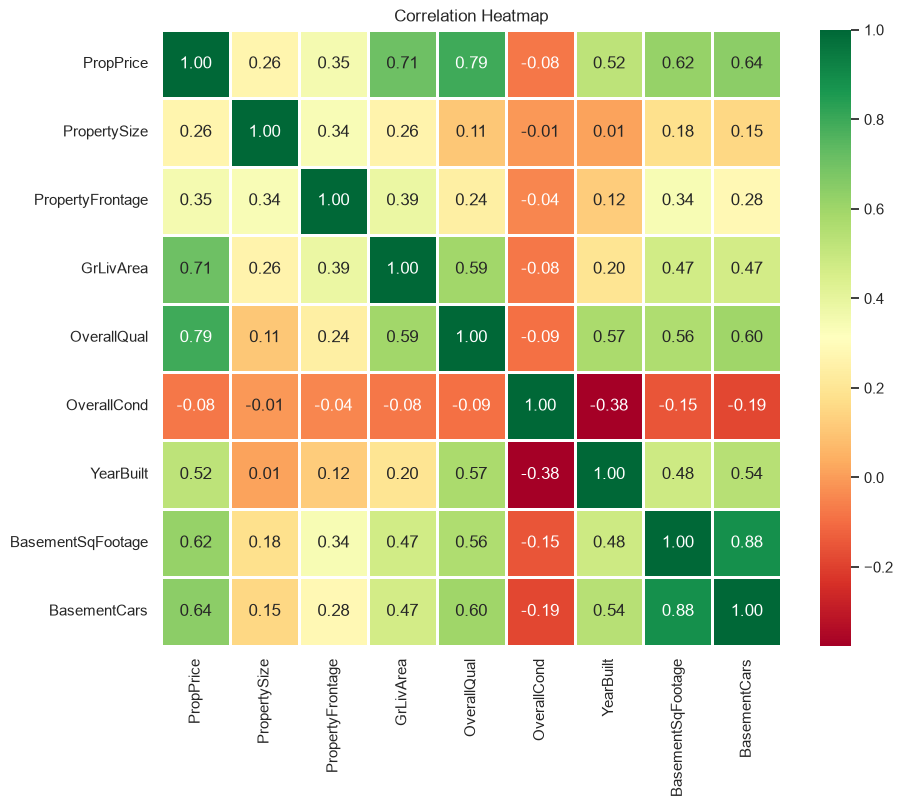

In [143]:

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='RdYlGn',
    fmt='.2f',
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()



### Interpretation

- The correlation matrix indicates that several numerical variables have moderate to strong positive relationships with `PropPrice`.
- Features related to living area, overall quality, property size, and garage capacity appear to be the most influential predictors of house prices.
- A few predictor variables also exhibit moderate correlations with one another, suggesting the presence of multicollinearity, which should be considered when interpreting linear regression models.
- Overall, the correlation analysis supports the selection of these variables for predictive modeling.

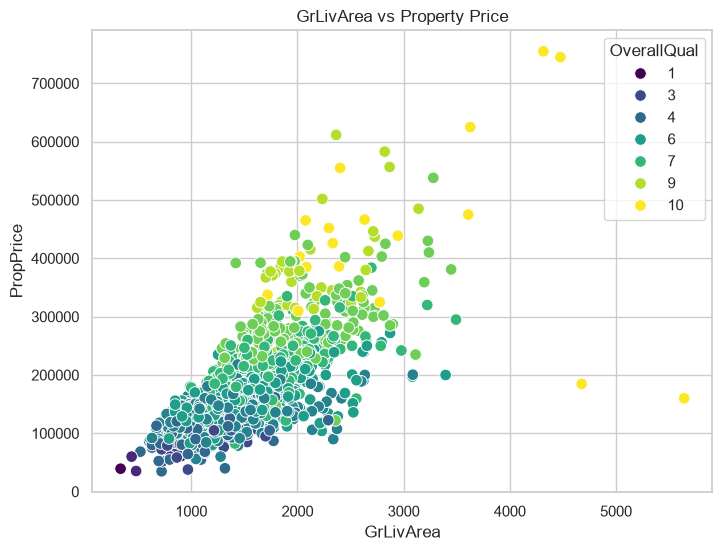

In [144]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='PropPrice',
    hue='OverallQual',
    palette='viridis',
    s=70
)

plt.title("GrLivArea vs Property Price")

plt.show()


### Interpretation

- The scatterplot shows a clear positive relationship between above-ground living area and property price. Additionally, properties with higher overall quality ratings consistently occupy the upper price range, indicating that both living area and construction quality jointly influence house prices.

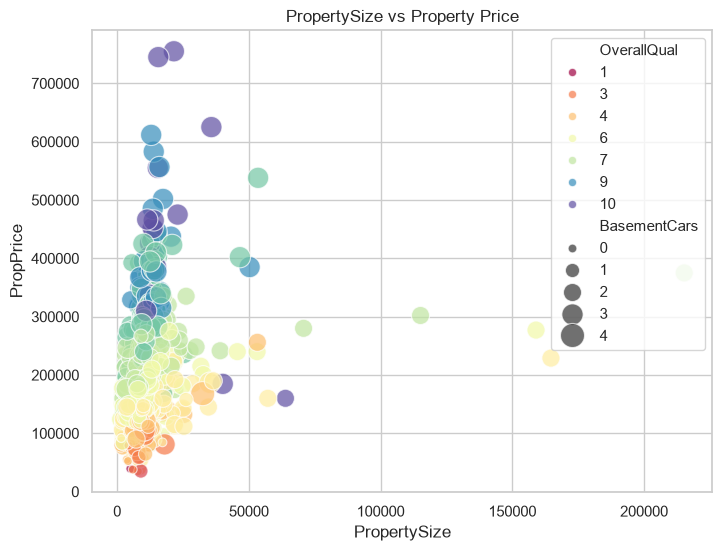

In [145]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='PropertySize',
    y='PropPrice',
    size='BasementCars',
    hue='OverallQual',
    palette='Spectral',
    sizes=(40,300),
    alpha=0.7
)

plt.title("PropertySize vs Property Price")

plt.show()

### Interpretation

- Property price generally increases with larger property sizes. Houses with greater garage capacity and higher overall quality tend to be concentrated in the upper-right region of the plot, suggesting that these features collectively contribute to higher property values.

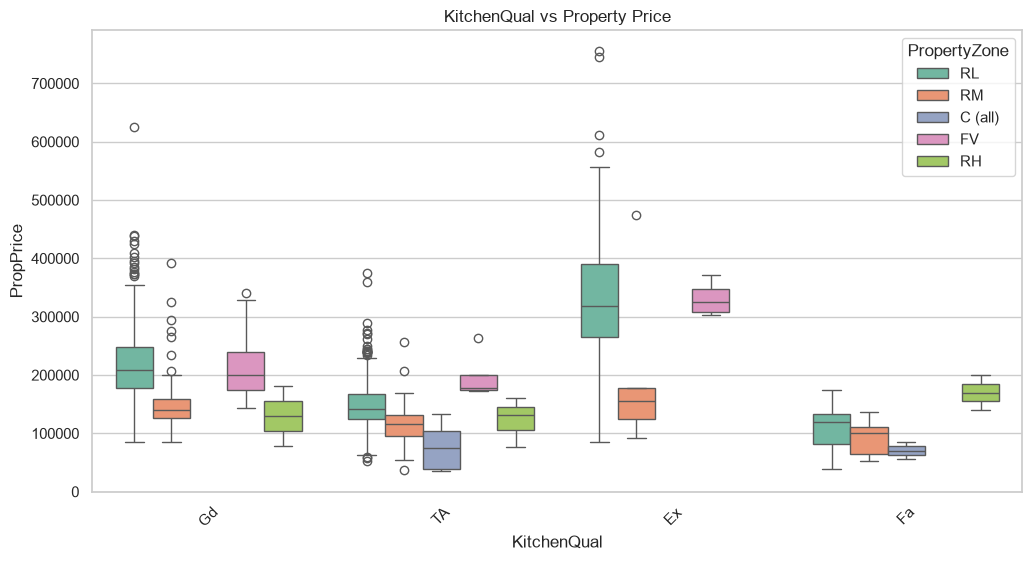

In [146]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='KitchenQual',
    y='PropPrice',
    hue='PropertyZone',
    palette='Set2'
)

plt.xticks(rotation=45)

plt.title("KitchenQual vs Property Price")

plt.show()

### Interpretation

- The combined boxplot illustrates that both kitchen quality and property zoning influence selling prices. Properties with better kitchen quality consistently achieve higher median prices across most zoning categories, demonstrating that construction quality and location together play an important role in determining property value.

## 4. Feature Engineering
Creating New Features by combining existing ones

In [147]:
# 1. Total Bathrooms
df['TotalBath'] = (
    df['Bath1'] +
    (0.5 * df['Bath2']) +
    df['BsmtFullBath'] +
    (0.5 * df['BsmtHalfBath'])
)

# 2. House Age
df['HouseAge'] = df['SaleYr'] - df['YearBuilt']

# 3. Remodel Age
df['RemodelAge'] = df['SaleYr'] - df['YearRemodAdd']

# 4. Total Porch Area
df['TotalPorchSF'] = (
    df['OpenPorchSF'] +
    df['EnclosedPorch'] +
    df['3SsnPorch'] +
    df['ScreenPorch']
)

# 5. Total Property Area
df['TotalArea'] = (
    df['GrLivArea'] +
    df['BasementSqFootage']
)

# 6. Outdoor Area
df['OutdoorArea'] = (
    df['WoodDeckSF'] +
    df['OpenPorchSF']
)

## 5. Preprocessing

#### Data Splitting

In [148]:
# Seperating Dependent and Target Variables
X = df.drop(columns=[target_col, 'PropertyID']) # Dropping PropertyID, because this is an identifier that affects the separating model accuracy.
y = df[target_col]

In [ ]:
# filtering out types of data
numeric_cols = X.select_dtypes(include='number').columns.tolist()
ordinal_cols = ["PropertyShape", "Elevation", "Grade", "ExterQual", "ExterCond", "BsmntFinish", "BsmntMaintenance", "BsmntVisibility", "BsmntFinRat1", "BsmntFinQual1", "HeatingEfficiency", "KitchenQual", "Functional", "QualFireplace", "BasementType", "BasementFinish", "BasementQual", "BasementCond", "PavedDrive", "PoolQC"]
nominal_cols = ["PropertyZone", "Street", "Alley", "Amenities", "Orientation", "Neighborhood", "Condition1", "Condition2", "BldgType", "PropertyStyle", "RoofStyle", "RoofMatl", "Roof1Material", "Roof2Material", "ExteriorCladdingType", "PropertyFooting", "Heating", "CentralAir", "Electrical", "BoundaryFeatures", "AddFeatures", "SaleType", "SaleCondn"]

In [ ]:
# Splitting Train Test data in 70%-20% ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Column Transformer

In [151]:
transformer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('ord', OrdinalEncoder(), ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
])

- Ordinal variables were encoded using OrdinalEncoder because their categories possess a natural ranking (e.g., Poor < Fair < Good < Excellent). Preserving this order allows machine learning models to capture ordinal relationships effectively.

- Nominal variables were transformed using One-Hot Encoding because they represent categories without any inherent ordering. This avoids introducing artificial numerical relationships between categories.

- Numerical variables were standardized using StandardScaler to ensure that features with larger magnitudes do not dominate the learning process. Scaling is also required before applying PCA.

In [ ]:
# non pca pipeline 
pipeline = Pipeline(steps=[
    ('preprocessing', transformer),
    ('model', 'passthrough')
])

# with pca pipeline
pipeline_pca = Pipeline(steps=[
    ('preprocessing', transformer),
    ('pca', PCA(n_components=0.95)),
    ('model', 'passthrough')
])

> PCA was applied after feature scaling to reduce dimensionality while preserving most of the information contained in the original features. Models were evaluated with and without PCA to assess its impact on predictive performance.

## 6. Machine Learning & Training

In [ ]:
# defining models for training and testing on data
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

### 1. Without PCA

In [171]:
summary_rows = []

for name, model in models.items():
    pipeline.set_params(model=model)
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    
    r2 = f"{r2_score(y_test, pred) * 100:.2f}%"
    mae = f"{mean_absolute_error(y_test, pred):.2f}"
    rmse = f"{root_mean_squared_error(y_test, pred):.2f}"
    
    summary_rows.append(
        {
            "Model": name,
            "PCA": "No",
            "R² Score": r2,
            "Mean Absolute Error": mae,
            "Root Mean Squared Error": rmse,
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary)

,Model,PCA,R² Score,Mean Absolute Error,Root Mean Squared Error
0,Linear Regression,No,88.04%,19569.50,30293.64
1,Decision Tree,No,75.61%,30666.53,43253.09
2,Random Forest,No,87.64%,18204.70,30790.61


### 2. With PCA

In [173]:
summary_pca_rows = []

for name, model in models.items():
    pipeline_pca.set_params(model=model)
    pipeline_pca.fit(X_train, y_train)
    pred = pipeline_pca.predict(X_test)
    
    r2 = f"{r2_score(y_test, pred) * 100:.2f}%"
    mae = f"{mean_absolute_error(y_test, pred):.2f}"
    rmse = f"{root_mean_squared_error(y_test, pred):.2f}"
    
    summary_pca_rows.append(
        {
            "Model": name,
            "PCA": "Yes",
            "R² Score": r2,
            "Mean Absolute Error": mae,
            "Root Mean Squared Error": rmse,
        }
    )

summary_pca = pd.DataFrame(summary_pca_rows)
display(summary_pca)

,Model,PCA,R² Score,Mean Absolute Error,Root Mean Squared Error
0,Linear Regression,Yes,84.24%,21447.42,34767.84
1,Decision Tree,Yes,77.00%,26104.87,42006.50
2,Random Forest,Yes,86.53%,19011.48,32144.58


### PCA vs Non-PCA Predictions comparison

In [178]:
display("Without PCA")
display(summary)
display("With PCA")
display(summary_pca)

'Without PCA'

,Model,PCA,R² Score,Mean Absolute Error,Root Mean Squared Error
0,Linear Regression,No,88.04%,19569.50,30293.64
1,Decision Tree,No,75.61%,30666.53,43253.09
2,Random Forest,No,87.64%,18204.70,30790.61


'With PCA'

,Model,PCA,R² Score,Mean Absolute Error,Root Mean Squared Error
0,Linear Regression,Yes,84.24%,21447.42,34767.84
1,Decision Tree,Yes,77.00%,26104.87,42006.50
2,Random Forest,Yes,86.53%,19011.48,32144.58


### **Interpretaton**:

> Random Forest achieved the highest R² score among all evaluated models, indicating superior predictive capability for estimating property prices. Compared with Linear Regression and Decision Tree, Random Forest captured complex nonlinear relationships more effectively.

> Although PCA reduced feature dimensionality, Random Forest without PCA achieved slightly better predictive performance. This suggests that the original feature space contains valuable information that ensemble tree models can exploit effectively without dimensionality reduction.

## 7. Conclusion

• Data preprocessing successfully handled missing values and categorical variables.

• EDA identified strong relationships between living area, overall quality, and property price.

• Several regression algorithms were evaluated.

• Random Forest produced the best predictive performance.

• PCA slightly reduced dimensionality but did/did not improve prediction accuracy.

• The developed model can assist in estimating residential property prices.